In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from graph import load

# 1. Load the data
print("Loading graph arrays...")
titles, edges, out_degree, dangling, categories = load()
N = len(titles)

# 2. Build the Sparse Matrix ONCE (saves massive computation time)
print("Constructing P^T transition matrix...")
sources = edges[:, 0]
targets = edges[:, 1]
data = 1.0 / out_degree[sources]

P_T = sp.csr_matrix((data, (targets, sources)), shape=(N, N))
print(f"Matrix ready! Shape: {P_T.shape}, Non-zeros: {P_T.nnz:,}")

Loading graph arrays...
Constructing P^T transition matrix...
Matrix ready! Shape: (293984, 293984), Non-zeros: 3,546,139


In [2]:
def track_convergence_errors(P_T, dangling, N, d, epsilon=1e-6, max_iter=150):
    """
    Runs the PageRank sparse engine but returns a list of the L1 errors 
    at each iteration instead of the final scores.
    """
    x = np.ones(N, dtype=np.float64) / N
    errors = []
    
    for iteration in range(1, max_iter + 1):
        link_mass = P_T.dot(x)
        lost_mass = np.sum(x[dangling])
        
        teleport_mass = (d * lost_mass / N) + ((1.0 - d) / N)
        x_next = (d * link_mass) + teleport_mass
        
        # Track the error for our plot
        error = np.sum(np.abs(x_next - x))
        errors.append(error)
        
        x = x_next
        
        if error < epsilon:
            break
            
    return errors

Running simulations...
  -> Tracking convergence for d = 0.50
  -> Tracking convergence for d = 0.75
  -> Tracking convergence for d = 0.85
  -> Tracking convergence for d = 0.90
  -> Tracking convergence for d = 0.95


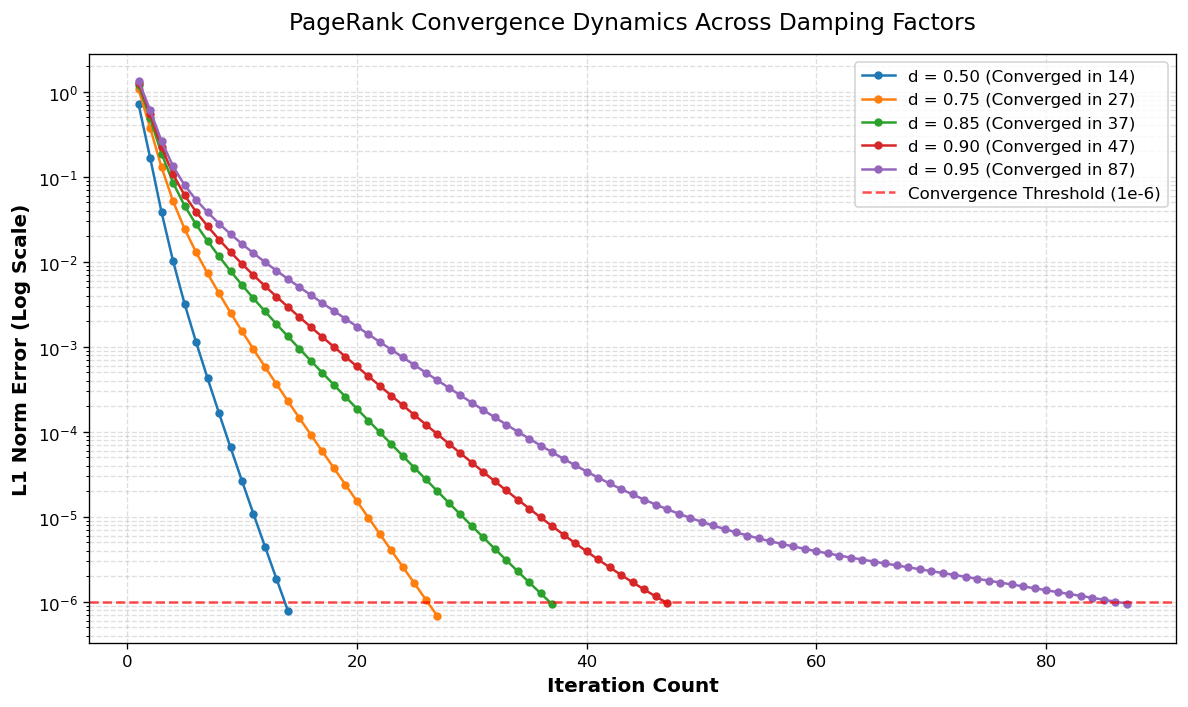

In [3]:
# We will test 5 different damping factors to see how they affect the speed
damping_factors = [0.50, 0.75, 0.85, 0.90, 0.95]
error_histories = {}

print("Running simulations...")
for d in damping_factors:
    print(f"  -> Tracking convergence for d = {d:.2f}")
    error_histories[d] = track_convergence_errors(P_T, dangling, N, d=d)

# Create a beautiful, publication-ready plot
plt.figure(figsize=(10, 6), dpi=120)

for d, errors in error_histories.items():
    plt.plot(
        range(1, len(errors) + 1), 
        errors, 
        marker='o', 
        markersize=4, 
        linewidth=1.5,
        label=f"d = {d:.2f} (Converged in {len(errors)})"
    )

# Formatting the plot
plt.yscale('log')  # A log scale is essential for viewing L1 decay!
plt.xlabel("Iteration Count", fontsize=12, fontweight='bold')
plt.ylabel("L1 Norm Error (Log Scale)", fontsize=12, fontweight='bold')
plt.title("PageRank Convergence Dynamics Across Damping Factors", fontsize=14, pad=15)

# Add a dashed line showing our strict cutoff threshold
plt.axhline(y=1e-6, color='red', linestyle='--', alpha=0.7, label="Convergence Threshold (1e-6)")

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()

# Display the chart inside VS Code
plt.show()